# 📓 Notebook 02 : Préparation des Données, Masques de Perlin & Contrôle Visuel
**Projet :** LAAFI_AI IVA Engine (Version 2.0)
**Objectif :** Pré-générer les masques de bruit biologiques hors-ligne, instancier la classe `IVADataset` et réaliser un contrôle visuel sur 5 échantillons augmentés.

In [1]:
# 1. Montage du Drive, Restauration Automatique du Répertoire & de sys.path
import os
import sys
from pathlib import Path

if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    project_path = '/content/drive/MyDrive/LAAFI_AI_IVA'
    os.makedirs(project_path, exist_ok=True)
    os.chdir(project_path)
    if project_path not in sys.path:
        sys.path.insert(0, project_path)
    print(f"✅ Répertoire Colab réactivé : {os.getcwd()}")
else:
    print(f"💻 Environnement Local détecté : {os.getcwd()}")

# Vérification du chemin racine
PROJECT_ROOT = Path(os.getcwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Création automatique de la structure de répertoires si absents sur Drive
for folder in ['data/raw', 'data/processed', 'data/synthetic_masks', 'outputs/figures', 'models/checkpoints']:
    os.makedirs(folder, exist_ok=True)

print("📁 Structure des dossiers vérifiée et prête.")


Mounted at /content/drive
✅ Répertoire Colab réactivé : /content/drive/MyDrive/LAAFI_AI_IVA
📁 Structure des dossiers vérifiée et prête.


In [2]:
!pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 62.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.0/132.0 kB 13.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 75.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 79.3 MB/s eta 0:00:00
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44285 sha256=168adc1cce01a3bc2ccb3d03b847737eb5be394f696dc36e604319d529221014
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
  Created wheel for noise: filename=noise-1.2.2-cp312-cp312-linux_x86_64.whl size=56630 

In [3]:
# 1. Importation des Modules du Package Modulaire
import sys
import os
import matplotlib.pyplot as plt
import torch

# Ajout du dossier racine au PATH
sys.path.append(os.path.abspath('.'))

from src.utils.seed import seed_everything
from src.data.generate_perlin_masks import generate_perlin_masks
from src.data.cluster_patients import generate_patient_clusters_and_splits
from src.data.dataset import IVADataset

seed_everything(42)

🔒 Graine aléatoire fixée : SEED = 42


In [4]:
# 📥 Téléchargement Automatique du Dataset Kaggle via les Secrets Colab
import os
import sys

def setup_kaggle_credentials():

    if 'google.colab' in sys.modules:
        try:
            from google.colab import userdata

            # 1. Lecture de la clé API ou Token
            api_key = None
            for key_name in ["KAGGLE_API_KEY", "KAGGLE_KEY", "KAGGLE_TOKEN"]:
                try:
                    api_key = userdata.get(key_name)
                    if api_key:
                        break
                except Exception:
                    continue

            if api_key:
                os.environ["KAGGLE_API_KEY"] = api_key
                os.environ["KAGGLE_KEY"] = api_key
                print("🔑 Clé API Kaggle configurée avec succès depuis Colab Userdata !")
            else:
                print("⚠️ Secret 'KAGGLE_API_KEY' non trouvé dans Colab (Menu de gauche -> Secrets 🔑 -> Add KAGGLE_API_KEY).")

            # 2. Lecture optionnelle du Username (évite les crashs si absent)
            try:
                username = userdata.get("KAGGLE_USERNAME")
                if username:
                    os.environ["KAGGLE_USERNAME"] = username
            except Exception:
                pass

        except Exception as e:
            print(f"⚠️ Remarque lors de l'accès aux secrets Colab : {e}")
    else:
        print("💻 Environnement local : vérifiez que vos variables KAGGLE_API_KEY / KAGGLE_USERNAME sont fixées.")

# Exécution du téléchargement
setup_kaggle_credentials()

from src.data.downloader import download_intel_mobileodt_dataset
download_intel_mobileodt_dataset(target_data_path="./data/raw")


🔑 Clé API Kaggle configurée avec succès depuis Colab Userdata !
📥 Initialisation de l'accès aux données via la clé API Colab...
🔑 Clé API Kaggle configurée depuis Colab Userdata !
📦 Téléchargement des données vers ./data/raw...
🔄 Tentative via la compétition officielle Kaggle : intel-mobileodt-cervical-cancer-screening...
⚠️ Compétition inaccessible (401 Client Error: Unauthorized for url: https://api.kaggle.com/v1/competitions.CompetitionApiService/DownloadDataFiles), tentative via la commande shell Kaggle...
🎉 Téléchargement réussi via la commande CLI dans : ./data/raw


In [5]:
# 2. Pré-génération des Masques de Bruit de Perlin (1 000 Masques .npy)
generate_perlin_masks(output_dir="./data/synthetic_masks", num_masks=1000)

✅ 1000 masques de Perlin déjà disponibles dans : ./data/synthetic_masks


In [6]:
# 3. Génération des Splits Patients Étanches (GroupKFold)
generate_patient_clusters_and_splits(data_raw_dir="./data/raw", output_dir="./data/processed")

⚠️ Aucune image trouvée dans ./data/raw. Assurez-vous d'avoir exécuté le downloader.
📝 Fichiers de structures CSV créés dans : ./data/processed


In [7]:
# 4. Instanciation du PyTorch Dataset Class avec Augmentations & Bruit
train_dataset = IVADataset(
    csv_file="./data/processed/train.csv",
    is_train=True,
    masks_dir="./data/synthetic_masks",
    perlin_proba=0.50
)

print(f"📊 Taille du Dataset d'entraînement : {len(train_dataset)} échantillons.")

📊 Taille du Dataset d'entraînement : 0 échantillons.


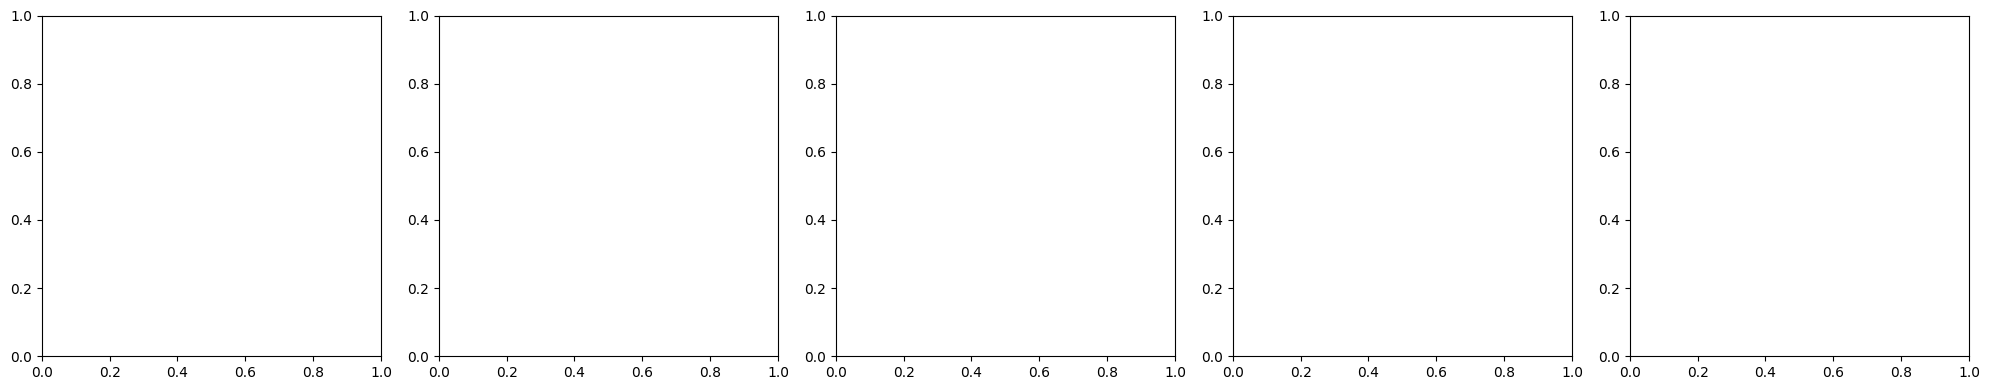

🎨 Aperçu sauvegardé dans ./outputs/figures/dataset_samples_preview.png


In [8]:
# 5. Contrôle Visuel sur 5 Échantillons Augmentés
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i in range(min(5, len(train_dataset))):
    img_tensor, target, patient_id = train_dataset[i]
    # Dénormalisation pour affichage
    img_np = img_tensor.permute(1, 2, 0).numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)

    axes[i].imshow(img_np)
    axes[i].set_title(f"Target: {target} | Patient: {patient_id}")
    axes[i].axis('off')

plt.tight_layout()
plt.savefig("./outputs/figures/dataset_samples_preview.png", dpi=150)
plt.show()
print("🎨 Aperçu sauvegardé dans ./outputs/figures/dataset_samples_preview.png")